## Customer Churn Prediction Using Machine Learning

**Introduction**

Customer churn occurs when a customer stops using a company's services. Predicting customer churn helps businesses identify customers who may leave and understand the factors associated with customer loss.

In this project, Machine Learning is used to predict whether a telecom customer will **churn or continue using the service**, based on information such as tenure, contract type, services, and billing details.

**Importance of the Project**

Customer retention is important for businesses because losing customers can affect revenue and growth. A churn prediction model can help companies identify customers who are more likely to leave and take suitable actions to improve customer retention.

The project follows the complete Machine Learning workflow, including data loading, data understanding, cleaning, preprocessing, feature selection, model building, prediction, and evaluation.

**Dataset:** Telco Customer Churn Dataset  
**Machine Learning Type:** Supervised Learning  
**Problem Type:** Binary Classification  
**Target Variable:** `Churn` — Yes/No

## 1. Data Loading & Understanding

In [8]:
import pandas as pd

df=pd.read_csv("Telco_customer_churn.csv")

df.head()
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()
df["Churn Label"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

The Telco Customer Churn dataset was loaded using Pandas and its basic structure was explored. The number of rows and columns, column names, data types, missing values, duplicate values, and basic statistics were checked. The **churn-related** columns were also examined, and Churn Label was selected as the target variable because it indicates whether a customer has left the service or not. This phase provided a basic understanding of the dataset before moving to data cleaning and preprocessing.

## 2.Data Cleaning & Preprocessing

In [13]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [18]:
df = df.drop(columns=["Count"])

In [21]:
df.columns.tolist()
df.dtypes

Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
CLTV                   int64
dtype: object

In [23]:
df["Total Charges"]=pd.to_numeric(df["Total Charges"],errors="coerce")
df.dtypes

Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
Churn Label           object
CLTV                   int64
dtype: object

In [24]:
x=df.drop("Churn Label",axis=1)
y=df["Churn Label"]

In [25]:
x.select_dtypes(include="object").columns

Index(['Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Online Security', 'Online Backup',
       'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
       'Contract', 'Paperless Billing', 'Payment Method'],
      dtype='object')

In [26]:
x.select_dtypes(exclude="object").columns

Index(['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges',
       'Total Charges', 'CLTV'],
      dtype='object')

The dataset was checked for missing values and duplicate records, and no missing or duplicate records were initially found. The constant **Count** column was removed because it does not provide useful information for prediction. The data types were examined, and **Total Charges** was converted to numeric format to make it suitable for Machine Learning. Categorical and numerical features were also identified as part of the preprocessing process.


## 3.Feature Preparation & Train-Test Split

In [63]:
location_columns = [
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long"
]

df_model = df.drop(columns=location_columns)

x= df_model.drop("Churn Label", axis=1)
y = df_model["Churn Label"]

In [66]:
x = pd.get_dummies(x, drop_first=True)

In [68]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (5634, 33)
Testing data: (1409, 33)


In this phase, the dataset was prepared for model building by removing unnecessary location-based columns such as **Country, State, City, Zip Code, and Lat Long** to reduce the number of high-cardinality features. The **Latitude and Longitude** features were retained as numerical geographical information. The target variable Churn Label was separated from the input features, and the categorical features were converted into numerical form using **one-hot encoding**. The prepared dataset was then divided into **80% training data (5,634 records) and 20% testing data (1,409 records)** using **train_test_split()** with **random_state=42**. After preprocessing, the model uses **33 input features**, making the dataset ready for model building and evaluation.

## 4.Model Building

In [86]:
median_value = x_train["Total Charges"].median()

x_train["Total Charges"] = x_train["Total Charges"].fillna(median_value)
x_test["Total Charges"] = x_test["Total Charges"].fillna(median_value)

print("Missing values in training data:", x_train.isnull().sum().sum())
print("Missing values in testing data:", x_test.isnull().sum().sum())

Missing values in training data: 0
Missing values in testing data: 0


In [87]:
y_train = df_model.loc[x_train.index, "Churn Label"].map({"Yes": 1, "No": 0})
y_test = df_model.loc[x_test.index, "Churn Label"].map({"Yes": 1, "No": 0})

print(y_train.value_counts())
print(y_test.value_counts())

Churn Label
0    4165
1    1469
Name: count, dtype: int64
Churn Label
0    1009
1     400
Name: count, dtype: int64


In [88]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [89]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)

In this phase, the prepared dataset was made ready for model training by handling the remaining missing values in the **Total Charges** feature using the median value from the training data. The numerical features were then standardized using **StandardScaler** to bring them to a similar scale. A **Logistic Regression** model was selected for this binary classification problem and trained using the prepared training data. The trained model was then used to predict the churn outcomes for the testing data.

## 5.Model Evaluation

In [90]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8026969481902059

Confusion Matrix:
[[901 108]
 [170 230]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1009
           1       0.68      0.57      0.62       400

    accuracy                           0.80      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



The Logistic Regression model was evaluated using accuracy, confusion matrix, precision, recall, and F1-score. The model achieved an accuracy of approximately **80.27%** on the testing data. The confusion matrix showed that the model correctly identified both churn and non-churn customers, although some customers who actually churned were incorrectly predicted as non-churn. For the churn class, the model achieved a precision of **0.68**, recall of **0.57**, and F1-score of **0.62**. These results provide an overall understanding of the model's performance and will be used for further analysis and comparison with other models.

## 6.Model Comparison

In [93]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)

In [94]:
from sklearn.metrics import accuracy_score, classification_report

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.7955997161107168

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.68      0.52      0.59       400

    accuracy                           0.80      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [95]:
print("Logistic Regression Accuracy:", accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Logistic Regression Accuracy: 0.8026969481902059
Random Forest Accuracy: 0.7955997161107168


In this phase, a Random Forest Classifier was trained and evaluated using the same training and testing data used for Logistic Regression. The Random Forest model achieved an accuracy of **79.56%**, while the Logistic Regression model achieved **80.27%** accuracy. The churn class was also compared using precision, recall, and F1-score. Logistic Regression achieved a churn recall of **0.57** and F1-score of **0.62**, while Random Forest achieved **0.52** recall and **0.59** F1-score. These results provide a basis for further analysis of the features contributing to customer churn.

## 7.Feature Importance & Insights

In [97]:
feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

                            Feature  Importance
2                     Tenure Months    0.129046
4                     Total Charges    0.125715
3                   Monthly Charges    0.103191
5                              CLTV    0.090127
0                          Latitude    0.087078
1                         Longitude    0.086601
13     Internet Service_Fiber optic    0.036133
31  Payment Method_Electronic check    0.032265
28                Contract_Two year    0.029523
9                    Dependents_Yes    0.029480


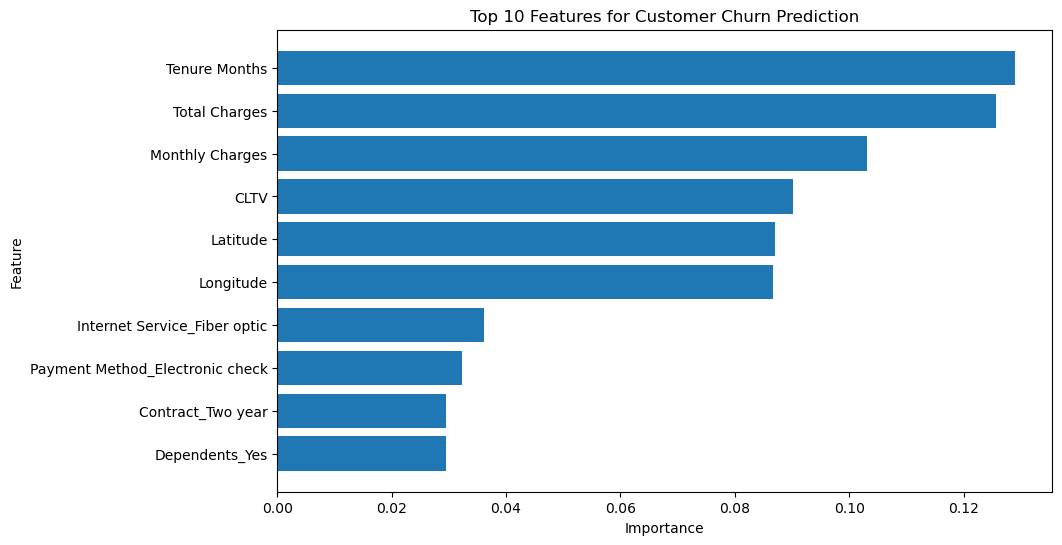

In [98]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features for Customer Churn Prediction")
plt.gca().invert_yaxis()
plt.show()

In this phase, feature importance was analyzed using the Random Forest model to understand which features contributed more to its predictions. The results showed that **Tenure Months, Total Charges, Monthly Charges, and CLTV** were among the most important features, followed by geographical and service-related features such as **Latitude, Longitude, Internet Service, and Payment Method**. A bar chart was created to visualize the top 10 important features. These insights help in understanding the factors that the model considered useful when predicting customer churn.

## 8.Final Results & Conclusion

In [99]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.802697
1        Random Forest  0.795600


This project developed a Machine Learning model to predict customer churn using the Telco Customer Churn dataset. The dataset was loaded, cleaned, preprocessed, and prepared for model training. Logistic Regression and Random Forest were trained and evaluated using the same testing data.
Logistic Regression achieved an accuracy of **80.27%**, while Random Forest achieved an accuracy of **79.56%**. The evaluation also included a confusion matrix, classification report, and feature importance analysis. The feature importance results showed that features such as **Tenure Months, Total Charges, Monthly Charges, and CLTV** had relatively higher importance in the Random Forest model.
Overall, the project demonstrates a complete Machine Learning workflow, from data preparation to model evaluation and interpretation. The results can help understand customer churn patterns and provide a foundation for further improvements to churn prediction.